In [ ]:
# now we will plot using pandas

In [1]:
# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [4]:
# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# sorting by date
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [8]:
# now lets group based on job_title_short
title_sorted = df['job_title_short'].value_counts()
title_sorted

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


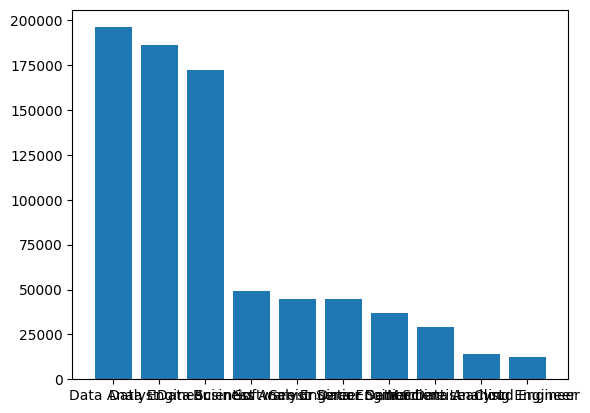

In [10]:
# using matplotlib
plt.bar(title_sorted.index, title_sorted.values)
plt.show()

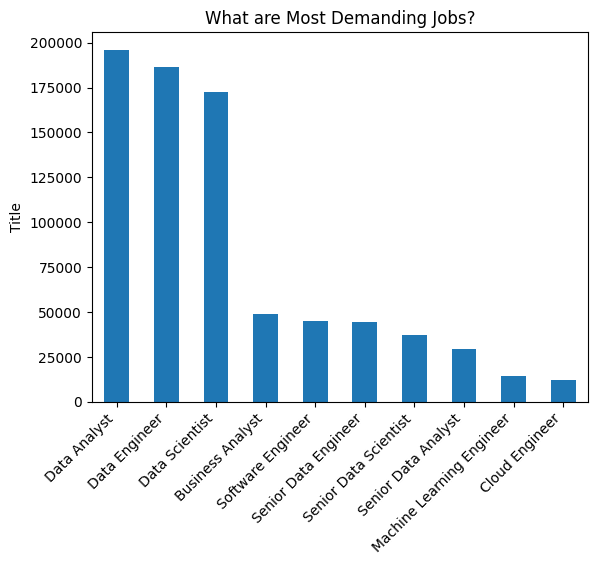

In [18]:
# using PANDAS
title_sorted.plot(kind='bar')

# Adding titles and labels
plt.title('What are Most Demanding Jobs?')
plt.xlabel('')
plt.ylabel('Title')

plt.xticks(rotation = 45, ha='right')


plt.show()



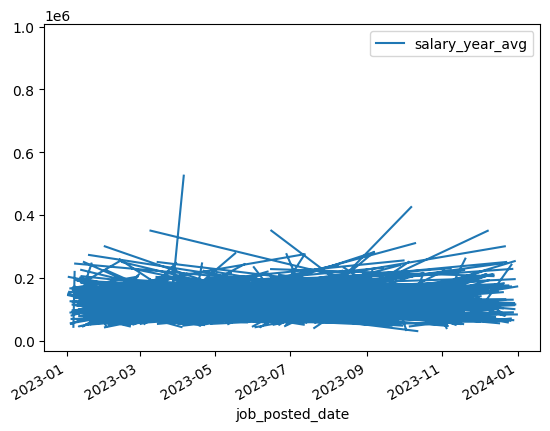

In [23]:
# now lets put another graph
df.plot(x='job_posted_date', y='salary_year_avg', kind='line')
plt.show()

In [24]:
# now lets apply the date as index for the dataframe
df = df.set_index('job_posted_date')
df.sort_index(inplace= True)
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_posted_date,,,,,,,,,,,,,,,,
2023-01-01 00:00:04,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",False,False,United States,None,NaN,NaN,Metasys Technologies,"['sql', 'snowflake', 'visio', 'jira', 'conflue...","{'analyst_tools': ['visio'], 'async': ['jira',..."
2023-01-01 00:00:07,Data Analyst,Data Analyst,"Bloomfield, CT",via CareerBuilder,Full-time,False,"New York, United States",True,False,United States,None,NaN,NaN,Diverse Lynx,"['sql', 'sas', 'sas']","{'analyst_tools': ['sas'], 'programming': ['sq..."
2023-01-01 00:00:22,Data Analyst,Data Analyst,"Washington, DC",via CareerBuilder,Full-time,False,"New York, United States",False,True,United States,None,NaN,NaN,Guidehouse,"['sql', 'python', 'r', 'azure', 'snowflake', '...","{'analyst_tools': ['tableau', 'excel'], 'cloud..."
2023-01-01 00:00:24,Data Analyst,Data Analyst,"Fairfax, VA",via CareerBuilder,Full-time,False,"New York, United States",False,False,United States,None,NaN,NaN,Protask,"['sql', 'jira']","{'async': ['jira'], 'programming': ['sql']}"
2023-01-01 00:00:27,Senior Data Analyst,Senior Data Analyst / Platform Experience,"Worcester, MA",via LinkedIn,Full-time,False,"New York, United States",False,True,United States,None,NaN,NaN,Atria Wealth Solutions,"['sql', 'atlassian', 'jira']","{'async': ['jira'], 'other': ['atlassian'], 'p..."


In [40]:
# now we will group according to job_title_short and calculate the median salary relating to them
Job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

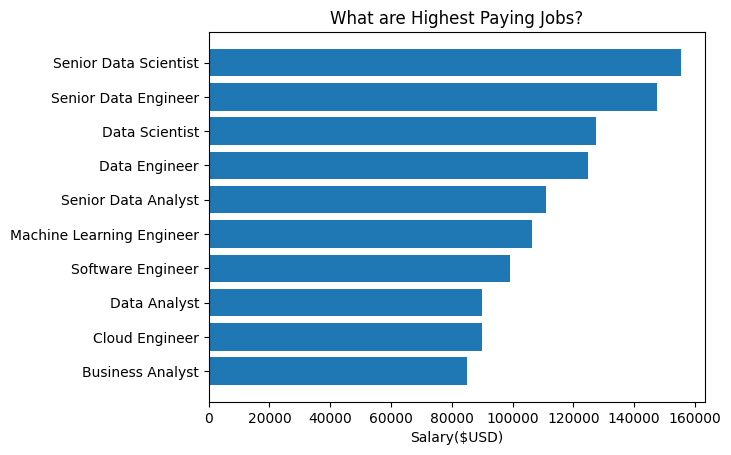

In [45]:
# now we will plot for the same
plt.barh(Job_salary.index, Job_salary.values)
plt.title('What are Highest Paying Jobs?')
plt.xlabel('Salary($USD)')
plt.ylabel('')

plt.show()